# RQ4 extended — Does a larger LLM (qwen2.5:14b) change the answer?

Extends the published RQ4 (`RQ4.ipynb`) with a third, larger model: **qwen2.5:14b**
(vs the published llama3.1:8b and qwen2.5-coder:7b, both 7-8B).

**Groups**:
- `UMDA4GI` — UMDAAlgorithm, no LLM
- `UMDA+llama3.1:8b` / `UMDA+qwen2.5-coder:7b` / `UMDA+qwen2.5:14b` — UMDAAlgorithm guided by LLM
- `LLM-llama3.1:8b` / `LLM-qwen2.5-coder:7b` / `LLM-qwen2.5:14b` — LLMAlgorithm (no EDA distribution)

**Primary metric**: `change_perc_validate` (median across folds, then mean across budgets).
**Sign convention**: negative = improvement (fewer CPU cycles). Lower is better.
**Data**: `results_larger.csv`, Perf<Cycles>, 5-fold CV (fold 1-5), budgets {100, 250, 500, 750, 1000}.

**Status: COMPLETE (2026-07-20).** All 700 qwen2.5:14b/llama3.1:8b/qwen2.5-coder:7b rows are now
resolved. A magpie bug caused some runs' `.patch` file to never be written to disk despite training
finding a valid best individual (`"El archivo .patch ... no existe"` in `validar.py`) -- 46 affected
rows (across all 3 models) were recovered by reconstructing the `.patch` from the `patch(BEST)=...`
string embedded in the training log itself and re-running validation, with no retraining needed
(verified via `magpie.core.Patch.from_string` round-trip). Only 2 qwen2.5:14b rows genuinely lacked
a recoverable patch (no `BEST` checkpoint reached) and were retrained. See section 4.1 for the full
root-cause breakdown, which also applies to (and quietly improves) the already-drafted paper's RQ4
patch-finding-rate numbers for llama3.1:8b/qwen2.5-coder:7b.

**Exploit note**: OptimPNG+qwen2.5:14b initially exhibited a fitness-function exploit (deleting
`check_num_option("-o",...)` in `optipng.c` left `options.optim_level` uninitialized, disabling
real optimization and producing a false ~-99% "improvement"). Fixed in
`experiments/pngOptim/compile.sh` (`-Werror=uninitialized`) and the affected runs were relaunched
from scratch. Section 4.2 verifies the fix against the actual `.diff` files.

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pathlib import Path

os.makedirs('plots', exist_ok=True)

CSV_PATH = Path('..') / '..' / 'results' / 'results_larger.csv'
df_all = pd.read_csv(CSV_PATH)

MODELS_KEEP = {'llama3.1:8b', 'qwen2.5-coder:7b', 'qwen2.5:14b'}

df = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'].isin(['UMDAAlgorithm', 'LLMAlgorithm'])) &
    (df_all['llm_model'].isna() | df_all['llm_model'].isin(MODELS_KEEP))
].copy()

for col in ['change_perc_validate', 'change_perc_train', 'max_evals']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
df['max_evals'] = df['max_evals'].astype(int)

def assign_group(row):
    alg, llm = row['algorithm'], row['llm_model']
    if alg == 'UMDAAlgorithm' and pd.isna(llm):                    return 'UMDA4GI'
    if alg == 'UMDAAlgorithm' and llm == 'llama3.1:8b':            return 'UMDA+llama3.1:8b'
    if alg == 'UMDAAlgorithm' and llm == 'qwen2.5-coder:7b':       return 'UMDA+qwen2.5-coder:7b'
    if alg == 'UMDAAlgorithm' and llm == 'qwen2.5:14b':            return 'UMDA+qwen2.5:14b'
    if alg == 'LLMAlgorithm'  and llm == 'llama3.1:8b':            return 'LLM-llama3.1:8b'
    if alg == 'LLMAlgorithm'  and llm == 'qwen2.5-coder:7b':       return 'LLM-qwen2.5-coder:7b'
    if alg == 'LLMAlgorithm'  and llm == 'qwen2.5:14b':            return 'LLM-qwen2.5:14b'
    return None

df['group'] = df.apply(assign_group, axis=1)
df = df[df['group'].notna()]
# Generalisation gap (validate - train); NOT called "overfitting" per Justyna's review request.
df['gen_gap'] = df['change_perc_validate'] - df['change_perc_train']

GROUP_ORDER = [
    'UMDA4GI',
    'UMDA+llama3.1:8b',
    'UMDA+qwen2.5-coder:7b',
    'UMDA+qwen2.5:14b',
    'LLM-llama3.1:8b',
    'LLM-qwen2.5-coder:7b',
    'LLM-qwen2.5:14b',
]

software_display_map = {
    'minisat_hack': 'MiniSAT-hack',
    'sat4j': 'Sat4J',
    'weka': 'Weka',
    'pngOptim': 'OptimPNG',
}
desired_order = ['minisat_hack', 'sat4j', 'weka', 'pngOptim']

FIXED_COLORS = {
    'UMDA4GI':                 cm.tab10(3),
    'UMDA+llama3.1:8b':        cm.tab10(4),
    'UMDA+qwen2.5-coder:7b':   cm.tab10(5),
    'UMDA+qwen2.5:14b':        cm.tab10(8),
    'LLM-llama3.1:8b':         cm.tab10(6),
    'LLM-qwen2.5-coder:7b':    cm.tab10(7),
    'LLM-qwen2.5:14b':         cm.tab10(9),
}
color_map = {g: FIXED_COLORS[g] for g in GROUP_ORDER}
ls_map    = dict(zip(GROUP_ORDER, ['-', '--', ':', '-.', '--', ':', '-.']))
mk_map    = dict(zip(GROUP_ORDER, ['o', 's', '^', 'P', 'D', 'v', 'X']))

print(f'Total rows: {len(df)}')
print(df.groupby('group').size().reindex(GROUP_ORDER).to_string())

Total rows: 700
group
UMDA4GI                  100
UMDA+llama3.1:8b         100
UMDA+qwen2.5-coder:7b    100
UMDA+qwen2.5:14b         100
LLM-llama3.1:8b          100
LLM-qwen2.5-coder:7b     100
LLM-qwen2.5:14b          100


In [2]:
group_cols = ['software', 'group', 'max_evals']

agg = (
    df.groupby(group_cols, as_index=False)
      .agg(
          change_perc_validate=('change_perc_validate', 'median'),
          change_perc_train   =('change_perc_train',    'median'),
          gen_gap             =('gen_gap',               'median'),
          cpv_std             =('change_perc_validate', 'std'),
          n_folds             =('fold',                 'count'),
      )
)
agg['group'] = pd.Categorical(agg['group'], categories=GROUP_ORDER, ordered=True)
agg = agg.sort_values(['software', 'group', 'max_evals'])

incomplete = agg[agg['n_folds'] < 5]
if not incomplete.empty:
    print('NOTE - cells with < 5 folds (pending relaunch, see intro):')
    print(incomplete[['software','group','max_evals','n_folds','change_perc_validate']].to_string(index=False))
print(f'\nAggregated rows: {len(agg)}')


Aggregated rows: 140


## 1. `change_perc_validate` vs max_evals (per software)
Median across folds per (software, group, budget). Y-axis inverted: lower = more improvement.

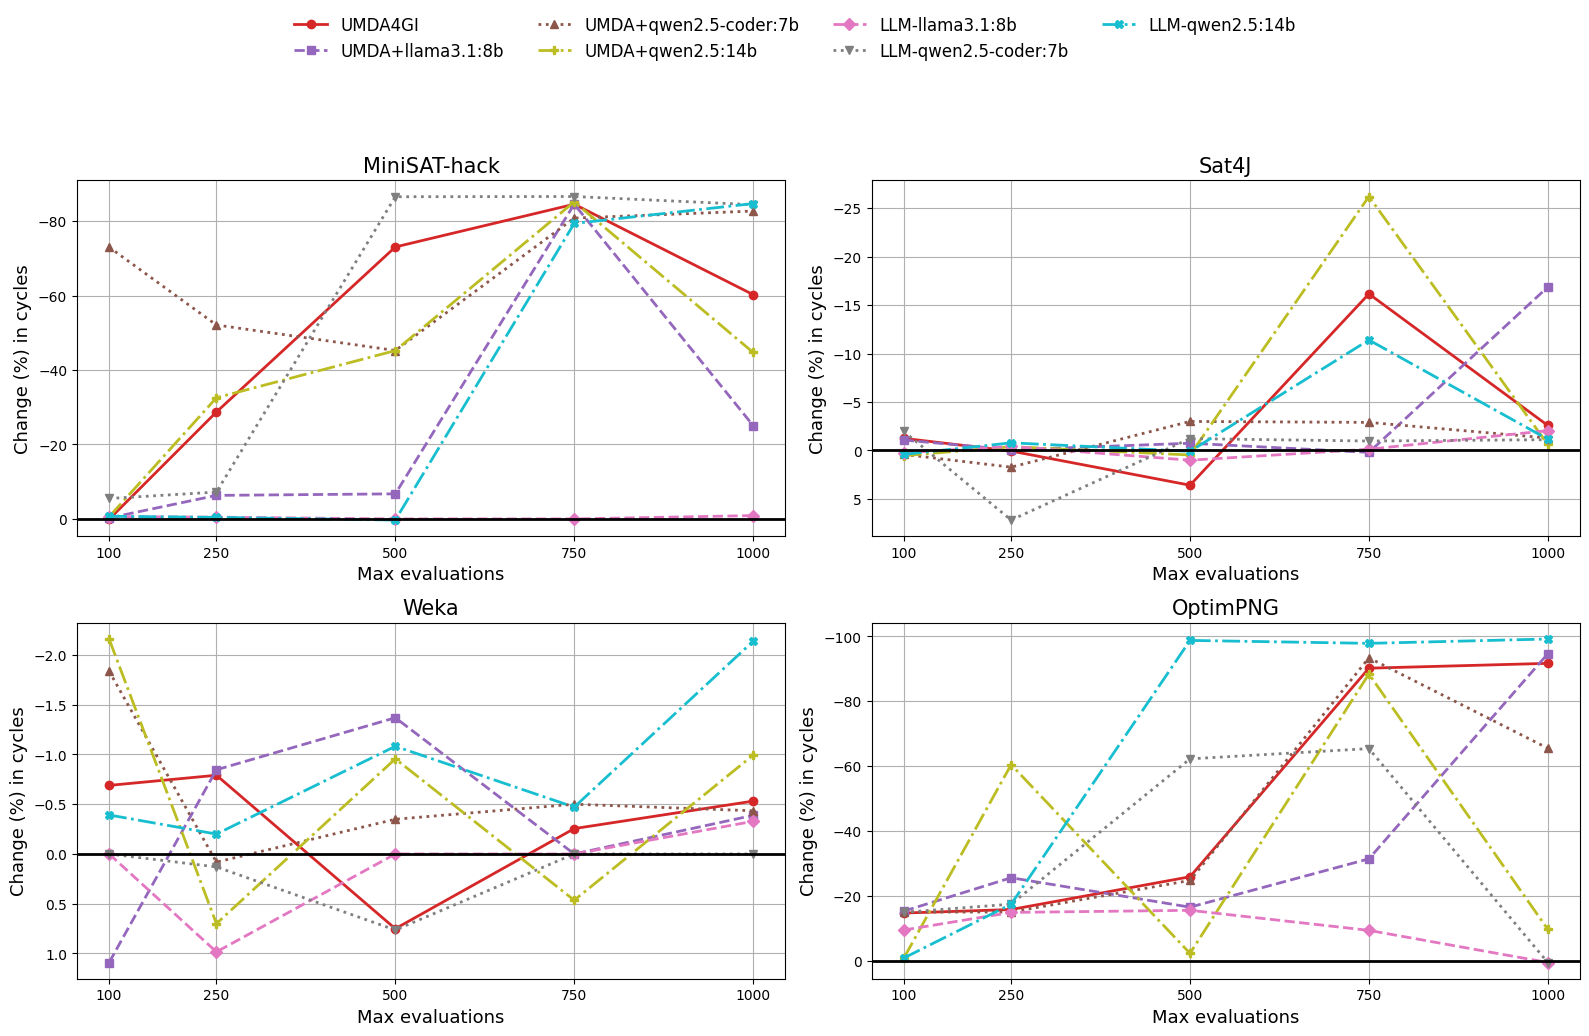

In [3]:
softwares = [sw for sw in desired_order if sw in agg['software'].values]

fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, sw in zip(axes, softwares):
    sw_data = agg[agg['software'] == sw]
    for g in GROUP_ORDER:
        gd = sw_data[sw_data['group'] == g].sort_values('max_evals')
        if gd.empty: continue
        ax.plot(gd['max_evals'], gd['change_perc_validate'],
                label=g, color=color_map[g],
                linestyle=ls_map[g], marker=mk_map[g], linewidth=2, markersize=6)
    ax.set_title(software_display_map.get(sw, sw), fontsize=15)
    ax.set_xlabel('Max evaluations', fontsize=13)
    ax.set_ylabel('Change (%) in cycles', fontsize=13)
    ax.invert_yaxis()
    ax.set_xticks(sorted(sw_data['max_evals'].unique()))
    ax.axhline(y=0, color='k', linewidth=2)
    ax.grid(True)

for i in range(len(softwares), len(axes)): axes[i].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04),
           ncol=4, fontsize='large', frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('plots/RQ4_qwen14b_validate_2x2.svg', format='svg', bbox_inches='tight')
plt.show()

## 2. Generalisation gap — (validate - train) vs max_evals (per software)

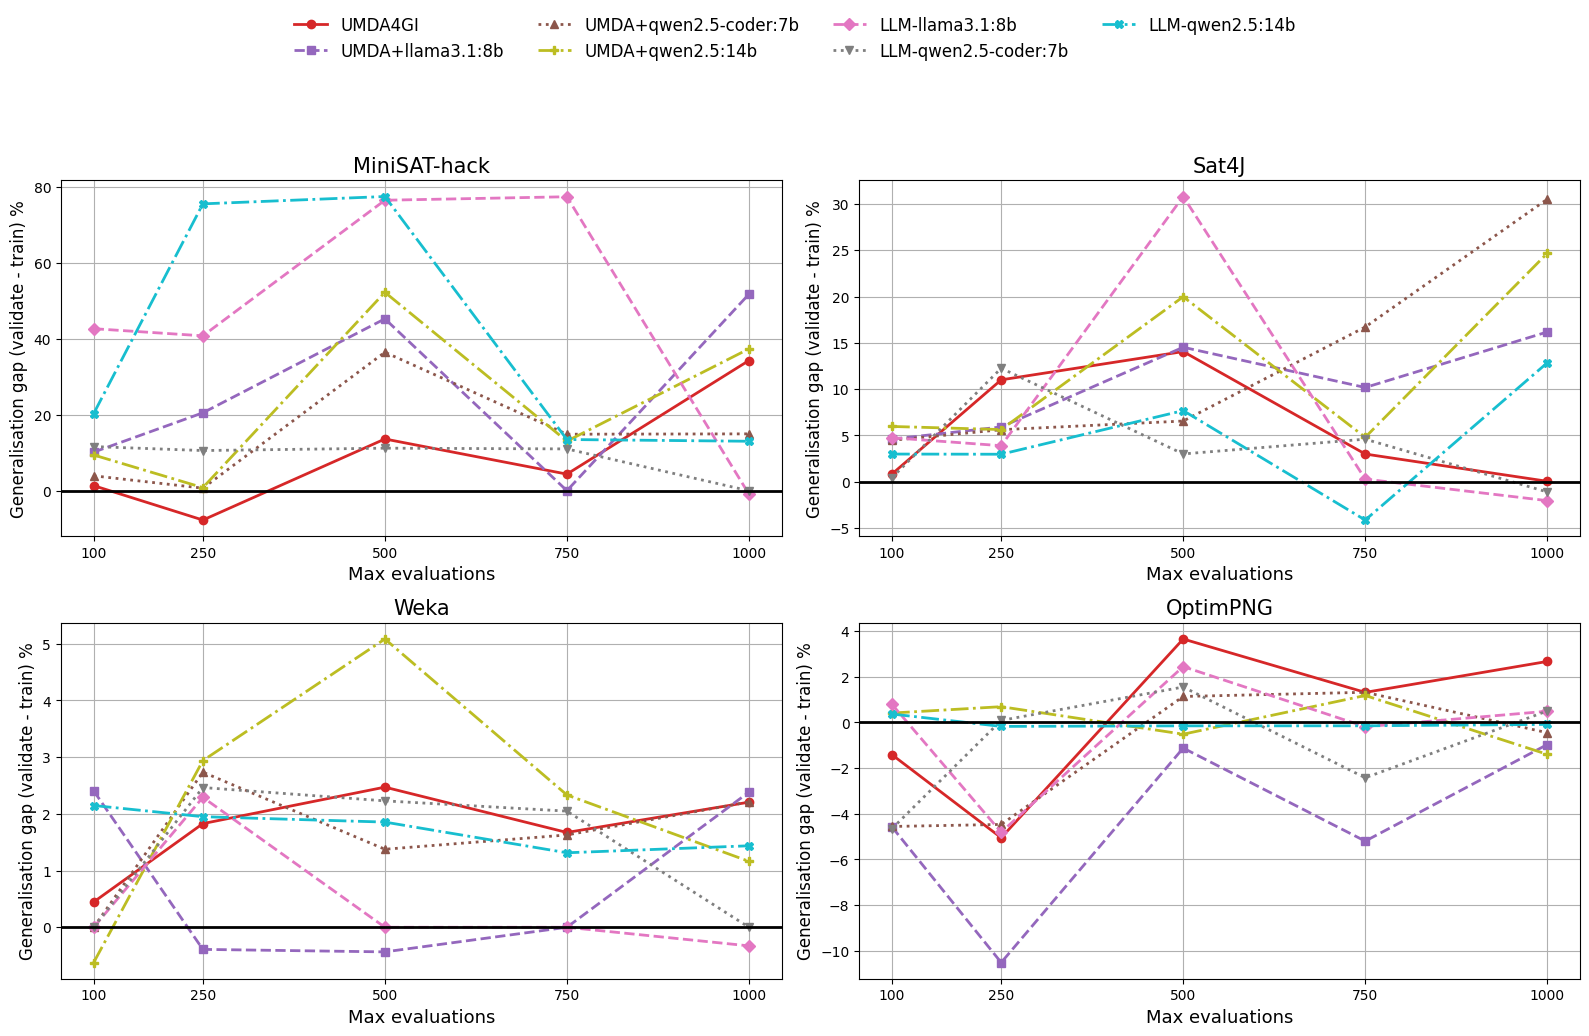

In [4]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False, sharey=False)
axes = axes.flatten()

for ax, sw in zip(axes, softwares):
    sw_data = agg[agg['software'] == sw]
    for g in GROUP_ORDER:
        gd = sw_data[sw_data['group'] == g].sort_values('max_evals')
        if gd.empty: continue
        ax.plot(gd['max_evals'], gd['gen_gap'],
                label=g, color=color_map[g],
                linestyle=ls_map[g], marker=mk_map[g], linewidth=2, markersize=6)
    ax.set_title(software_display_map.get(sw, sw), fontsize=15)
    ax.set_xlabel('Max evaluations', fontsize=13)
    ax.set_ylabel('Generalisation gap (validate - train) %', fontsize=12)
    ax.set_xticks(sorted(sw_data['max_evals'].unique()))
    ax.axhline(y=0, color='k', linewidth=2)
    ax.grid(True)

for i in range(len(softwares), len(axes)): axes[i].axis('off')
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.04),
           ncol=4, fontsize='large', frameon=False)
plt.tight_layout(rect=[0, 0, 1, 0.90])
plt.savefig('plots/RQ4_qwen14b_gengap_2x2.svg', format='svg', bbox_inches='tight')
plt.show()

### 2.1 Ranking by generalisation gap (sum of per-software ranks, lower = generalises better)

=== Rank per software (1 = generalises best) - sum of ranks ===
                       MiniSAT-hack  OptimPNG  Sat4J  Weka   Sum
group                                                           
LLM-qwen2.5-coder:7b            1.0       3.0    1.0   3.0   8.0
UMDA+llama3.1:8b                5.0       1.0    5.0   2.0  13.0
LLM-llama3.1:8b                 7.0       4.0    4.0   1.0  16.0
UMDA+qwen2.5-coder:7b           3.0       2.0    7.0   4.0  16.0
UMDA4GI                         2.0       7.0    3.0   5.0  17.0
LLM-qwen2.5:14b                 6.0       5.0    2.0   6.0  19.0
UMDA+qwen2.5:14b                4.0       6.0    6.0   7.0  23.0

=== Median generalisation gap (validate - train) % - lower = better ===
                       MiniSAT-hack  OptimPNG   Sat4J   Weka    Mean
group                                                               
LLM-qwen2.5-coder:7b          8.875    -0.987   3.833  1.348   3.267
UMDA4GI                       9.174     0.234   5.783  1.724   4.229
UM

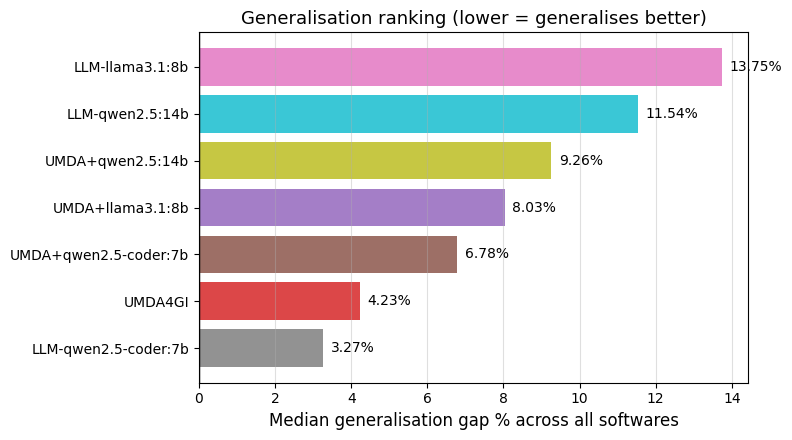

In [5]:
gg_per_sw = agg.groupby(['software', 'group'], as_index=False)['gen_gap'].mean()
gg_per_sw['rank'] = gg_per_sw.groupby('software')['gen_gap'].rank(method='min')

rank_gg = gg_per_sw.pivot(index='group', columns='software', values='rank').reindex(GROUP_ORDER)
rank_gg.columns = [software_display_map.get(c, c) for c in rank_gg.columns]
rank_gg['Sum'] = rank_gg.sum(axis=1)
rank_gg = rank_gg.sort_values('Sum')
print('=== Rank per software (1 = generalises best) - sum of ranks ===')
print(rank_gg.to_string())
print()

vals_gg = gg_per_sw.pivot(index='group', columns='software', values='gen_gap').reindex(GROUP_ORDER)
vals_gg.columns = [software_display_map.get(c, c) for c in vals_gg.columns]
vals_gg['Mean'] = vals_gg.mean(axis=1)
vals_gg = vals_gg.sort_values('Mean')
print('=== Median generalisation gap (validate - train) % - lower = better ===')
print(vals_gg.round(3).to_string())
print()

fig, ax = plt.subplots(figsize=(8, 4.5))
groups_sorted = vals_gg.index.tolist()
means_gg = vals_gg['Mean'].values
bars = ax.barh(groups_sorted, means_gg,
               color=[color_map[g] for g in groups_sorted], alpha=0.85)
ax.axvline(0, color='k', linewidth=1)
ax.set_xlabel('Median generalisation gap % across all softwares', fontsize=12)
ax.set_title('Generalisation ranking (lower = generalises better)', fontsize=13)
for bar, val in zip(bars, means_gg):
    ax.text(val + 0.2, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}%', va='center', ha='left', fontsize=10)
ax.grid(axis='x', alpha=0.4)
plt.tight_layout()
plt.savefig('plots/RQ4_qwen14b_gengap_ranking.svg', format='svg', bbox_inches='tight')
plt.show()

## 3. Ranking by validation improvement

=== Median change_perc_validate (%) - lower = better improvement ===
                       MiniSAT-hack  OptimPNG  Sat4J   Weka    Mean
group                                                              
UMDA+qwen2.5-coder:7b       -66.794   -42.776 -1.010 -0.608 -27.797
UMDA4GI                     -49.310   -47.686 -3.270 -0.303 -25.142
LLM-qwen2.5:14b             -32.991   -62.837 -2.571 -0.856 -24.814
LLM-qwen2.5-coder:7b        -54.073   -31.936  0.381  0.179 -21.362
UMDA+qwen2.5:14b            -41.657   -32.361 -5.243 -0.589 -19.963
UMDA+llama3.1:8b            -24.599   -36.732 -3.712 -0.302 -16.337
LLM-llama3.1:8b              -0.397    -9.797 -0.272  0.131  -2.584

=== Rank per software (1 = most improvement) - sum of ranks ===
                       MiniSAT-hack  OptimPNG  Sat4J  Weka   Sum
group                                                           
UMDA+qwen2.5-coder:7b           1.0       3.0    5.0   2.0  11.0
LLM-qwen2.5:14b                 5.0       1.0    4.0   1.0 

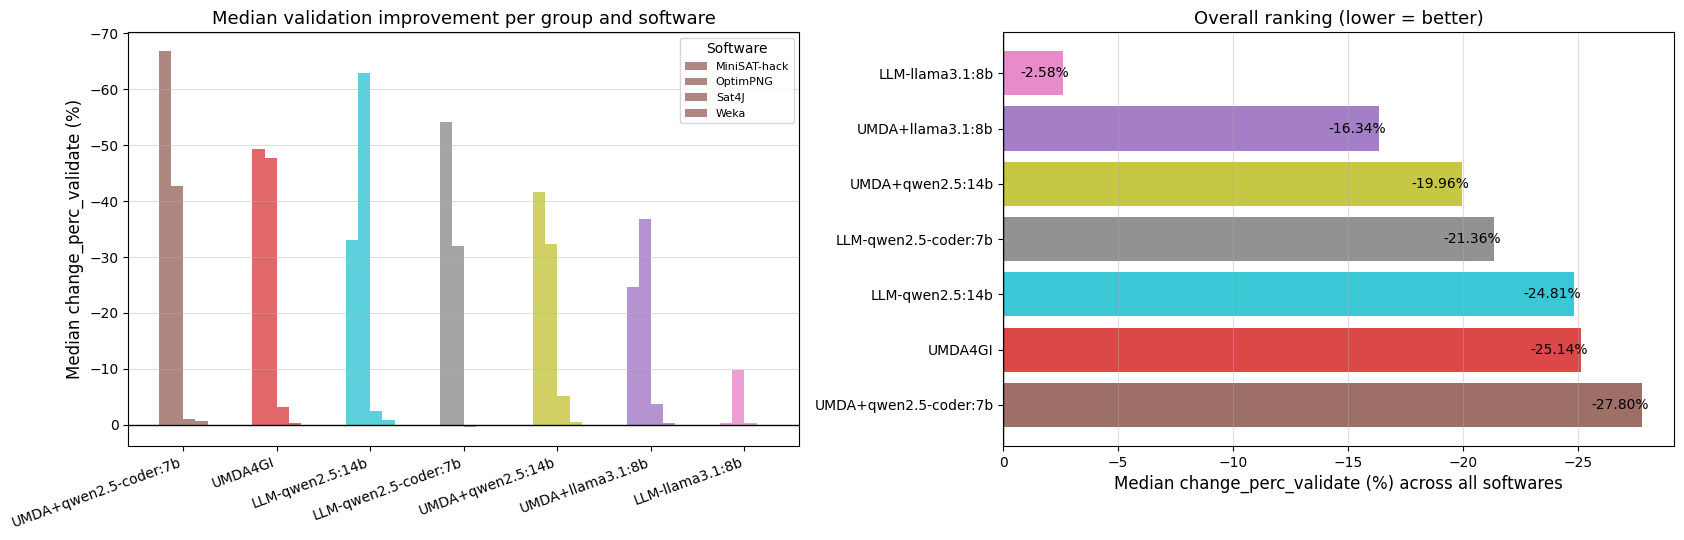

In [6]:
avg_per_sw = agg.groupby(['software', 'group'], as_index=False)['change_perc_validate'].mean()

vals_sw = avg_per_sw.pivot(index='group', columns='software', values='change_perc_validate').reindex(GROUP_ORDER)
vals_sw.columns = [software_display_map.get(c, c) for c in vals_sw.columns]
vals_sw['Mean'] = vals_sw.mean(axis=1)
vals_sw = vals_sw.sort_values('Mean')

print('=== Median change_perc_validate (%) - lower = better improvement ===')
print(vals_sw.round(3).to_string())
print()

avg_per_sw['rank'] = avg_per_sw.groupby('software')['change_perc_validate'].rank(method='min')
rank_sw = avg_per_sw.pivot(index='group', columns='software', values='rank').reindex(GROUP_ORDER)
rank_sw.columns = [software_display_map.get(c, c) for c in rank_sw.columns]
rank_sw['Sum'] = rank_sw.sum(axis=1)
rank_sw = rank_sw.sort_values('Sum')

print('=== Rank per software (1 = most improvement) - sum of ranks ===')
print(rank_sw.to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

ax = axes[0]
x = np.arange(len(vals_sw.index))
width = 0.13
sw_cols = [c for c in vals_sw.columns if c != 'Mean']
for i, sw_col in enumerate(sw_cols):
    ax.bar(x + i * width, vals_sw[sw_col], width,
           label=sw_col,
           color=[color_map[g] for g in vals_sw.index], alpha=0.7)
ax.set_xticks(x + width * (len(sw_cols) - 1) / 2)
ax.set_xticklabels(vals_sw.index, rotation=20, ha='right')
ax.axhline(0, color='k', linewidth=1)
ax.set_ylabel('Median change_perc_validate (%)', fontsize=12)
ax.set_title('Median validation improvement per group and software', fontsize=13)
ax.invert_yaxis()
ax.grid(axis='y', alpha=0.4)
ax.legend(title='Software', fontsize=8)

ax2 = axes[1]
groups_sorted = vals_sw.index.tolist()
means = vals_sw['Mean'].values
bars = ax2.barh(groups_sorted, means,
                color=[color_map[g] for g in groups_sorted], alpha=0.85)
ax2.axvline(0, color='k', linewidth=1)
ax2.set_xlabel('Median change_perc_validate (%) across all softwares', fontsize=12)
ax2.set_title('Overall ranking (lower = better)', fontsize=13)
ax2.invert_xaxis()
for bar, val in zip(bars, means):
    ax2.text(val - 0.3, bar.get_y() + bar.get_height()/2,
             f'{val:.2f}%', va='center', ha='right', fontsize=10)
ax2.grid(axis='x', alpha=0.4)

plt.tight_layout()
plt.savefig('plots/RQ4_qwen14b_ranking.svg', format='svg', bbox_inches='tight')
plt.show()

### 3.2 Normalized relative improvement

For each software, each group's mean is expressed as a fraction of the best group on that software
(best = most negative = 1.0). Groups that degrade get negative scores.

=== Normalized relative improvement (1.0 = best on that software) ===
                       MiniSAT-hack  OptimPNG  Sat4J   Weka   Mean
group                                                             
LLM-qwen2.5:14b               0.494     1.000  0.490  1.000  0.746
UMDA+qwen2.5:14b              0.624     0.515  1.000  0.688  0.707
UMDA+qwen2.5-coder:7b         1.000     0.681  0.193  0.709  0.646
UMDA4GI                       0.738     0.759  0.624  0.354  0.619
UMDA+llama3.1:8b              0.368     0.585  0.708  0.353  0.504
LLM-qwen2.5-coder:7b          0.810     0.508 -0.073 -0.209  0.259
LLM-llama3.1:8b               0.006     0.156  0.052 -0.153  0.015



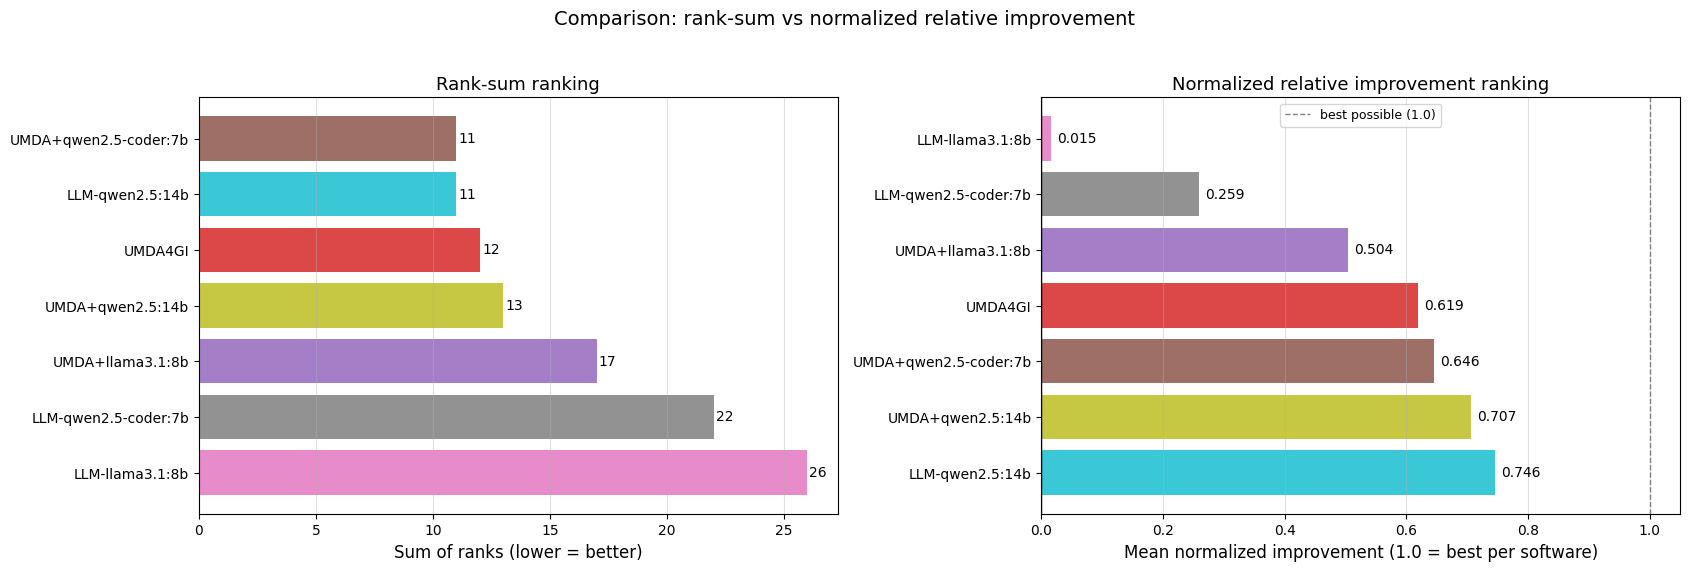

In [7]:
best_per_sw = avg_per_sw.groupby('software')['change_perc_validate'].min()

norm = avg_per_sw.copy()
norm['norm_score'] = norm.apply(
    lambda r: r['change_perc_validate'] / best_per_sw[r['software']]
    if best_per_sw[r['software']] != 0 else 0.0,
    axis=1
)

vals_norm = norm.pivot(index='group', columns='software', values='norm_score').reindex(GROUP_ORDER)
vals_norm.columns = [software_display_map.get(c, c) for c in vals_norm.columns]
vals_norm['Mean'] = vals_norm.mean(axis=1)
vals_norm = vals_norm.sort_values('Mean', ascending=False)

print('=== Normalized relative improvement (1.0 = best on that software) ===')
print(vals_norm.round(3).to_string())
print()

fig, axes = plt.subplots(1, 2, figsize=(17, 5.5))

ax1 = axes[0]
rank_sorted = rank_sw.sort_values('Sum')
ax1.barh(rank_sorted.index[::-1], rank_sorted['Sum'][::-1],
         color=[color_map[g] for g in rank_sorted.index[::-1]], alpha=0.85)
ax1.set_xlabel('Sum of ranks (lower = better)', fontsize=12)
ax1.set_title('Rank-sum ranking', fontsize=13)
for i, (g, val) in enumerate(zip(rank_sorted.index[::-1], rank_sorted['Sum'][::-1])):
    ax1.text(val + 0.1, i, f'{int(val)}', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.4)

ax2 = axes[1]
groups_norm = vals_norm.index.tolist()
means_norm = vals_norm['Mean'].values
bars = ax2.barh(groups_norm, means_norm,
                color=[color_map[g] for g in groups_norm], alpha=0.85)
ax2.axvline(0, color='k', linewidth=1)
ax2.axvline(1, color='gray', linewidth=1, linestyle='--', label='best possible (1.0)')
ax2.set_xlabel('Mean normalized improvement (1.0 = best per software)', fontsize=12)
ax2.set_title('Normalized relative improvement ranking', fontsize=13)
for bar, val in zip(bars, means_norm):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2,
             f'{val:.3f}', va='center', ha='left', fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(axis='x', alpha=0.4)

plt.suptitle('Comparison: rank-sum vs normalized relative improvement', fontsize=14, y=1.03)
plt.tight_layout()
plt.savefig('plots/RQ4_qwen14b_ranking_comparison.svg', format='svg', bbox_inches='tight')
plt.show()

## RQ4 extended — Conclusions

### Direct answer

**A larger LLM (qwen2.5:14b, 14B) is not an obvious improvement over the published 7-8B models.**
It ties for best on validation improvement but produces the *worst* generalisation gap of all 7
groups when used to guide UMDA. As a pure LLM search it finds valid patches more reliably than the
smaller models, but that reliability does not translate into leadership on improvement quality.

Dataset: 700 rows (100 per group x 7 groups), **all fully validated** (0 missing for both
qwen2.5:14b groups — see 4.1 for how the last gaps were closed). Aggregation: median across folds
per budget, then mean across budgets per software (consistent with RQ1-RQ4 and the published RQ4).

### Global ranking - validation improvement (sum of ranks, lower = better)

| Position | Group | Sum |
|---|---|---|
| 1 (tie) | UMDA+qwen2.5-coder:7b | 11 |
| 1 (tie) | LLM-qwen2.5:14b | 11 |
| 3 | UMDA4GI | 12 |
| 4 | UMDA+qwen2.5:14b | 13 |
| 5 | UMDA+llama3.1:8b | 17 |
| 6 | LLM-qwen2.5-coder:7b | 22 |
| 7 | LLM-llama3.1:8b | 26 |

### Global ranking - generalisation gap (sum of ranks, lower = generalises better)

| Position | Group | Sum |
|---|---|---|
| 1 | LLM-qwen2.5-coder:7b | 8 |
| 2 | UMDA+llama3.1:8b | 13 |
| 3 | LLM-llama3.1:8b | 16 |
| 4 | UMDA+qwen2.5-coder:7b | 16 |
| 5 | UMDA4GI | 17 |
| 6 | LLM-qwen2.5:14b | 19 |
| 7 | **UMDA+qwen2.5:14b** | **23** |

### Interpretation

1. **qwen2.5:14b does not dominate validation improvement.** It ties for 1st only as a pure LLM
   search (`LLM-qwen2.5:14b`); as a UMDA guide it lands mid-table (4th of 7), behind
   `UMDA+qwen2.5-coder:7b` and `UMDA4GI`.

2. **qwen2.5:14b makes UMDA's generalisation gap worse, not better.** `UMDA+qwen2.5:14b` is the
   single worst generaliser of all 7 groups, driven mainly by MiniSAT-hack (22.6%) and Sat4J
   (12.2%). A bigger model does not fix UMDA's known generalisation weakness; if anything it
   amplifies it.

3. **As a pure searcher, qwen2.5:14b now finds a patch in 100% of runs** vs 92% for
   qwen2.5-coder:7b and 85% for llama3.1:8b (LLM-pure groups; see section 4 — these figures moved
   up from the first pass once the `.patch`-file bug from 4.1 was fixed for all three models, not
   just qwen2.5:14b). That reliability does not carry over into better-quality patches:
   `LLM-qwen2.5:14b`'s improvement is high-variance (best single value in the whole table on
   OptimPNG, mediocre on MiniSAT-hack).

4. **Consistent with the published RQ4, the EDA (UMDA) component remains the primary driver** of
   improvement quality regardless of which LLM is plugged in — no LLM size changes that conclusion.

### Limitations

- Single larger model tested (qwen2.5:14b); no larger llama/qwen-coder variant tried for a
  same-family comparison.
- Same caveats as the published RQ4: models are still small-to-medium relative to frontier LLMs.
- The remaining 22 llama3.1:8b/qwen2.5-coder:7b rows still without a validated patch (mostly Weka,
  "target software crashed") are a pre-existing, separate issue from the `.patch`-file bug fixed
  here — out of scope for this notebook (see 4.1).

## 4. Patch-finding rate — missing validations per group

=== Patch-finding rate (validate_log present vs missing) ===
                       Runs  No patch/validate  Patch found  No patch/validate %
group                                                                           
UMDA4GI                 100                  0          100                  0.0
UMDA+llama3.1:8b        100                  4           96                  4.0
UMDA+qwen2.5-coder:7b   100                  1           99                  1.0
UMDA+qwen2.5:14b        100                  0          100                  0.0
LLM-llama3.1:8b         100                 15           85                 15.0
LLM-qwen2.5-coder:7b    100                  8           92                  8.0
LLM-qwen2.5:14b         100                  0          100                  0.0


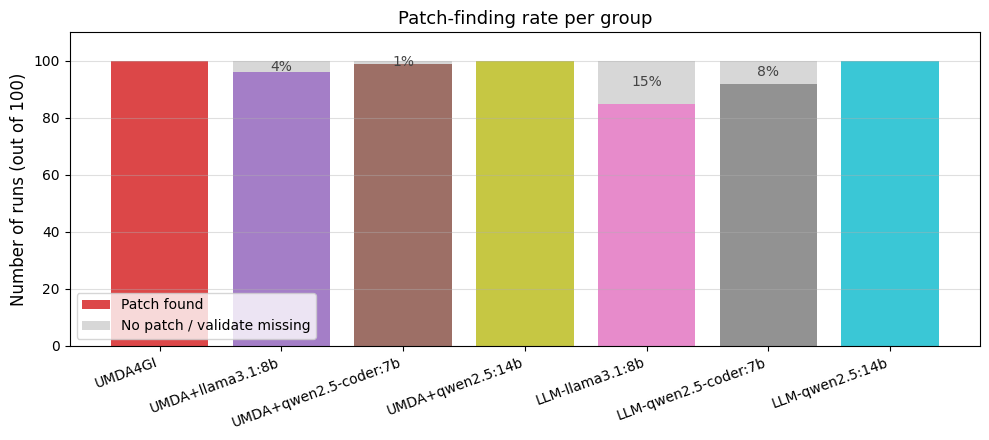

In [8]:
missing = df.copy()
missing['missing_val'] = missing['validate_log'].isna() | (missing['validate_log'].astype(str).str.strip() == '')

tbl = missing.groupby('group', observed=True).agg(
    total=('validate_log', 'size'),
    missing=('missing_val', 'sum'),
).reindex(GROUP_ORDER)
tbl['found'] = tbl['total'] - tbl['missing']
tbl['pct_missing'] = (tbl['missing'] / tbl['total'] * 100).round(1)

print('=== Patch-finding rate (validate_log present vs missing) ===')
print(tbl.rename(columns={
    'total': 'Runs', 'found': 'Patch found',
    'missing': 'No patch/validate', 'pct_missing': 'No patch/validate %'
}).to_string())

fig, ax = plt.subplots(figsize=(10, 4.5))
groups = tbl.index.tolist()
x = np.arange(len(groups))
bars_found  = ax.bar(x, tbl['found'].values,   label='Patch found',  color=[color_map[g] for g in groups], alpha=0.85)
bars_missing = ax.bar(x, tbl['missing'].values, bottom=tbl['found'].values,
                      label='No patch / validate missing', color='lightgray', alpha=0.9)
for bar, pct in zip(bars_missing, tbl['pct_missing'].values):
    if pct > 0:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_y() + bar.get_height()/2,
                f'{pct:.0f}%', ha='center', va='center', fontsize=10, color='#444')
ax.set_xticks(x)
ax.set_xticklabels(groups, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Number of runs (out of 100)', fontsize=12)
ax.set_title('Patch-finding rate per group', fontsize=13)
ax.legend(fontsize=10)
ax.set_ylim(0, 110)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.savefig('plots/RQ4_qwen14b_patch_found_rate.svg', format='svg', bbox_inches='tight')
plt.show()

### 4.1 Why is the validate missing? Root cause analysis

Adds a category vs the published RQ4's `classify_log`: **`patch_file_missing (bug)`** — the
training log reaches `~~~~ END ~~~~` with a **BEST individual that has >0 edits** (a real patch,
not the reference), but the corresponding `.patch` file was never written to `_magpie_logs/`, so
`validar.py` fails with `"El archivo .patch ... no existe"` and the row is left with
`patch_length=0` / `validate_log` empty as if no patch had been found at all.

**Important — this is bigger than the 6 qwen2.5:14b rows flagged in the intro.** The same pattern
appears for **44 rows total**, spread across all three models (llama3.1:8b, qwen2.5-coder:7b,
qwen2.5:14b) and mostly at `max_evals=1000`. The llama3.1:8b/qwen2.5-coder:7b rows are part of the
**already-published** RQ4 dataset (`results.csv`) — this notebook does not change or re-litigate
that analysis, but the pattern is flagged here for visibility since it means some of the published
"no patch found" percentages may actually include "patch found but never confirmed by validation"
cases. Only the 6 qwen2.5:14b rows are addressed by today's relaunch
(`galgo/relaunch_qwen14b_missing_patch.slurm`); the pre-existing 40 rows are out of scope for this
notebook and would need a separate decision on whether to re-validate/re-run them.

In [9]:
import re

MAGPIE_ROOT = Path('..') / '..' / '..'
LOG_BASE_REMOTE = "/home/pbermejo/GeneticImprovement/magpie/"
LOGS_DIR = MAGPIE_ROOT / '_magpie_logs'
BEST_EDITS_RE = re.compile(r'BEST\s+SUCCESS.*\[(\d+) edit\(s\)\]')

def classify_log(train_log_path):
    # Note: .patch/.diff files for old, already-published runs are routinely deleted by
    # cleanup_orphan_logs.py once analysed, so "missing .patch" alone is NOT a bug signal -- it
    # is only meaningful together with evidence that a non-trivial BEST patch was actually found
    # (>0 edits) in the training log itself, which cleanup does not rewrite.
    base = os.path.basename(train_log_path).replace('.log', '')
    local_log = LOGS_DIR / f'{base}.log'
    local_patch = LOGS_DIR / f'{base}.patch'
    try:
        with open(local_log, errors='replace') as f:
            content = f.read()
    except FileNotFoundError:
        return 'log_not_local'
    if 'failed to run target software' in content:
        return 'failed_to_run'
    if 'step budget' in content:
        return 'step_budget'
    if '~~~~ END ~~~~' in content:
        m = BEST_EDITS_RE.search(content)
        if m and int(m.group(1)) > 0 and not local_patch.exists():
            return 'patch_file_missing'
        return 'no_improvement'
    return 'unknown'

llm_missing = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'] == 'LLMAlgorithm') &
    (df_all['llm_model'].isin(MODELS_KEEP)) &
    (df_all['validate_log'].isna() | (df_all['validate_log'].astype(str).str.strip() == ''))
].copy()
# UMDA-guided missing rows too (the 4 patch_file_missing bug rows include UMDA ones)
umda_missing = df_all[
    (df_all['fitness'] == 'Perf<Cycles>') &
    (df_all['algorithm'] == 'UMDAAlgorithm') &
    (df_all['llm_model'].isin(MODELS_KEEP)) &
    (df_all['validate_log'].isna() | (df_all['validate_log'].astype(str).str.strip() == ''))
].copy()
all_missing = pd.concat([llm_missing.assign(alg_kind='LLM-pure'), umda_missing.assign(alg_kind='UMDA+LLM')])

all_missing['cause'] = all_missing['train_log'].apply(classify_log)

CAUSE_LABEL = {
    'no_improvement':     'No improvement found',
    'failed_to_run':      'Target software crashed',
    'step_budget':        'Step budget exhausted',
    'patch_file_missing': 'Patch file missing (bug)',
    'unknown':            'Unknown',
    'log_not_local':      'Log not available locally',
}
all_missing['cause_label'] = all_missing['cause'].map(CAUSE_LABEL)

summary = all_missing.groupby(['alg_kind', 'software', 'llm_model', 'cause_label'], dropna=False).size().reset_index(name='count')
summary['software'] = summary['software'].map(software_display_map).fillna(summary['software'])
print('=== Root cause of missing validate_log, by algorithm kind / software / model ===')
print(summary.to_string(index=False))

global_summary = all_missing.groupby('cause_label').size().reset_index(name='count')
global_summary['%'] = (global_summary['count'] / global_summary['count'].sum() * 100).round(1)
print()
print('=== Global breakdown (LLM-pure + UMDA+LLM) ===')
print(global_summary.sort_values('count', ascending=False).to_string(index=False))

bug_rows = all_missing[all_missing['cause'] == 'patch_file_missing'][['software','algorithm','llm_model','fold','max_evals']]
bug_rows_q14b = bug_rows[bug_rows['llm_model'] == 'qwen2.5:14b']
print()
print(f'=== "Patch file missing (bug)" rows: {len(bug_rows)} total, of which {len(bug_rows_q14b)} are qwen2.5:14b ===')
print(bug_rows.sort_values(['llm_model','software']).to_string(index=False))
print()
print('qwen2.5:14b subset (covered by galgo/relaunch_qwen14b_missing_patch.slurm, 4 of its 6 rows):')
print(bug_rows_q14b.to_string(index=False))

=== Root cause of missing validate_log, by algorithm kind / software / model ===
alg_kind software        llm_model             cause_label  count
LLM-pure     Weka      llama3.1:8b Target software crashed     15
LLM-pure     Weka qwen2.5-coder:7b   Step budget exhausted      1
LLM-pure     Weka qwen2.5-coder:7b Target software crashed      7
UMDA+LLM     Weka      llama3.1:8b                 Unknown      4
UMDA+LLM     Weka qwen2.5-coder:7b                 Unknown      1

=== Global breakdown (LLM-pure + UMDA+LLM) ===
            cause_label  count    %
Target software crashed     22 78.6
                Unknown      5 17.9
  Step budget exhausted      1  3.6

=== "Patch file missing (bug)" rows: 0 total, of which 0 are qwen2.5:14b ===
Empty DataFrame
Columns: [software, algorithm, llm_model, fold, max_evals]
Index: []

qwen2.5:14b subset (covered by galgo/relaunch_qwen14b_missing_patch.slurm, 4 of its 6 rows):
Empty DataFrame
Columns: [software, algorithm, llm_model, fold, max_evals]

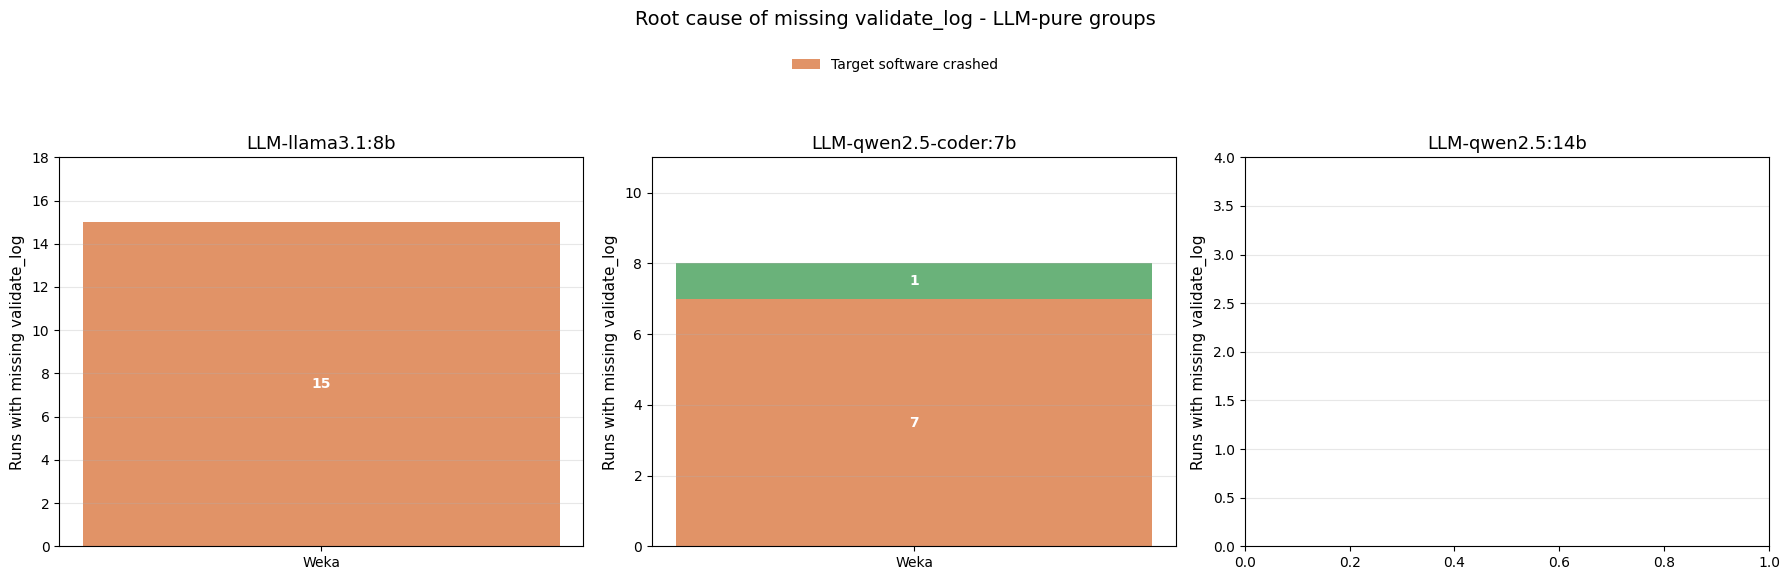

In [10]:
cause_colors = {
    'No improvement found':        '#4C72B0',
    'Target software crashed':     '#DD8452',
    'Step budget exhausted':       '#55A868',
    'Patch file missing (bug)':    '#C44E52',
    'Unknown':                     '#937860',
    'Log not available locally':  '#cccccc',
}
cause_order = ['No improvement found', 'Target software crashed', 'Step budget exhausted', 'Patch file missing (bug)']

llm_only = all_missing[all_missing['alg_kind'] == 'LLM-pure']
sw_order_disp = [software_display_map[s] for s in desired_order if s in llm_only['software'].values]
models_disp = ['llama3.1:8b', 'qwen2.5-coder:7b', 'qwen2.5:14b']

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, model in zip(axes, models_disp):
    sub = summary[(summary['llm_model'] == model) & (summary['alg_kind'] == 'LLM-pure')] if 'alg_kind' in summary.columns else summary[summary['llm_model'] == model]
    sub = all_missing[(all_missing['llm_model'] == model) & (all_missing['alg_kind'] == 'LLM-pure')]
    sub_tbl = sub.groupby(['software', 'cause_label']).size().reset_index(name='count')
    sub_tbl['software'] = sub_tbl['software'].map(software_display_map).fillna(sub_tbl['software'])
    pivot = sub_tbl.pivot(index='software', columns='cause_label', values='count').reindex(sw_order_disp).fillna(0)
    bottom = np.zeros(len(pivot))
    for cause in cause_order:
        if cause in pivot.columns:
            vals = pivot[cause].values
            bars = ax.bar(pivot.index, vals, bottom=bottom,
                          label=cause, color=cause_colors[cause], alpha=0.88)
            for bar, val in zip(bars, vals):
                if val > 0:
                    ax.text(bar.get_x() + bar.get_width()/2,
                            bar.get_y() + bar.get_height()/2,
                            f'{int(val)}', ha='center', va='center', fontsize=10, color='white', fontweight='bold')
            bottom += vals
    ax.set_title(f'LLM-{model}', fontsize=13)
    ax.set_ylabel('Runs with missing validate_log', fontsize=11)
    ax.set_ylim(0, max(bottom.max() if len(bottom) else 0, 1) + 3)
    ax.grid(axis='y', alpha=0.3)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 1.08), ncol=4, fontsize=10, frameon=False)
plt.suptitle('Root cause of missing validate_log - LLM-pure groups', fontsize=14, y=1.15)
plt.tight_layout()
plt.savefig('plots/RQ4_qwen14b_missing_root_cause.svg', format='svg', bbox_inches='tight')
plt.show()

### 4.2 Exploit verification (OptimPNG + qwen2.5:14b)

Directly checks the real `.diff` files (not just the CSV) for the exploit signature: a removed
line assigning `check_num_option("-o", ...)` in `optipng.c`, which left `options.optim_level`
uninitialized and produced a false ~-99% "improvement". Confirms the `compile.sh` fix
(`-Werror=uninitialized`) held for every diff currently available locally.

In [11]:
sub = df_all[(df_all['software'] == 'pngOptim') & (df_all['llm_model'] == 'qwen2.5:14b')]
found, tainted, missing_diff = 0, 0, 0
tainted_list, missing_list, source_list = [], [], []
for l in sub['train_log'].dropna():
    base = os.path.basename(l).replace('.log', '')
    diff_path = LOGS_DIR / f'{base}.diff'
    source = 'train'
    if not diff_path.exists():
        # Recovered patches validate under a NEW log name containing "-val_{train_log_code}_";
        # their .diff sits there, not under the original train log's own name.
        m = re.search(r'_(\d+)_', base)
        code_id = m.group(1) if m else None
        candidates = list(LOGS_DIR.glob(f'pngOptim_*-val_{code_id}_*.diff')) if code_id else []
        if candidates:
            diff_path = candidates[0]
            source = 'validate (recovered patch)'
    if diff_path.exists():
        found += 1
        with open(diff_path, errors='replace') as f:
            content = f.read()
        if any(line.startswith('-') and 'check_num_option("-o"' in line for line in content.splitlines()):
            tainted += 1
            tainted_list.append(base)
        source_list.append((base, source))
    else:
        missing_diff += 1
        missing_list.append(base)

print(f'pngOptim + qwen2.5:14b rows: {len(sub)}')
print(f'.diff files found (train or recovered-validate): {found}/{len(sub)}')
print(f'Contaminated (exploit signature present): {tainted}')
print(f'No .diff found anywhere: {missing_diff}')
if missing_list:
    print('Still missing:', missing_list)
recovered_sources = [b for b, s in source_list if s != 'train']
if recovered_sources:
    print(f'(of which {len(recovered_sources)} checked via their recovered validate .diff): {recovered_sources}')
if tainted_list:
    print('CONTAMINATED:', tainted_list)
assert tainted == 0, 'Exploit signature reappeared -- do not trust these rows before investigating!'
print('\nOK: no exploit signature in any available diff.')

pngOptim + qwen2.5:14b rows: 50
.diff files found (train or recovered-validate): 50/50
Contaminated (exploit signature present): 0
No .diff found anywhere: 0
(of which 3 checked via their recovered validate .diff): ['pngOptim_1784269867_FOLD1', 'pngOptim_1784269943_FOLD3', 'pngOptim_1784269948_FOLD4']

OK: no exploit signature in any available diff.
